# Signal processes statistical analysis

In [1]:
from pathlib import Path
from diquark.config.config_manager import ConfigManager
from diquark.data.loader import DataLoader

config_files_dir = Path(".").absolute().parent / "diquark" / "config"

config_file_path = config_files_dir / "New_Features" / "ATLAS_136_S7000_B6500_32j_5f.yaml"
assert config_file_path.exists()

config = ConfigManager(config_file_path)

# Load signal config file
signal_config_file = config.get_required("data.signal_file")
backgrounds_config_file_path = config_files_dir / "Signals" / signal_config_file
signal_config = ConfigManager(backgrounds_config_file_path)

signal_file = Path(signal_config.get("signal.file"))

path_dict = {"SIG:Suu": signal_file}

data_loader = DataLoader(
    path_dict,
    index_start=0,
    index_stop=None,
)

In [2]:
mass_cut = config.get_required("data.mass_cut")
data = data_loader.load_data(mass_cut)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Fraction of events passing mass cut: 0.94


In [3]:
from diquark.features.feature_extractor import FeatureExtractor

print("Extracting features...")
feature_extractor = FeatureExtractor(n_jets=32, chi_mass=2000, suu_mass=8000)

signal_features = feature_extractor.compute_all(data["SIG:Suu"])
print(f"Working with {len(signal_features.keys())} feature columns")

Extracting features...
Working with 60 feature columns


In [4]:
print(signal_features.keys())

dict_keys(['jet_multiplicity', 'p_T_min', 'p_T_mean', 'p_T_stddev', 'p_T_max', 'eta_min', 'eta_mean', 'eta_stddev', 'eta_max', 'phi_min', 'phi_mean', 'phi_stddev', 'phi_max', 'delta_r_min', 'delta_r_mean', 'delta_r_stddev', 'delta_r_max', 'sphericity', 'aplanarity', 'centrality', 'total_energy', 'total_p_T', 'combined_invariant_mass', 'm2j_min', 'm2j_mean', 'm2j_stddev', 'm2j_max', 'm3j_min', 'm3j_mean', 'm3j_stddev', 'm3j_max', 'm6j_min', 'm6j_mean', 'm6j_stddev', 'm6j_max', 'vector_sum_p_T_2j_min', 'vector_sum_p_T_2j_mean', 'vector_sum_p_T_2j_stddev', 'vector_sum_p_T_2j_max', 'vector_sum_p_T_3j_min', 'vector_sum_p_T_3j_mean', 'vector_sum_p_T_3j_stddev', 'vector_sum_p_T_3j_max', 'vector_sum_p_T_6j_min', 'vector_sum_p_T_6j_mean', 'vector_sum_p_T_6j_stddev', 'vector_sum_p_T_6j_max', 'n_jet_pairs_near_w_mass', 'chi2_first_component_min', 'chi2_first_component_mean', 'chi2_first_component_stddev', 'chi2_first_component_max', 'chi2_second_component_min', 'chi2_second_component_mean', 'chi2

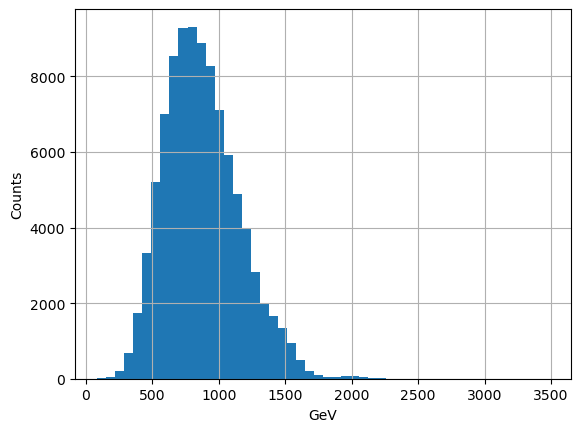

In [5]:
import matplotlib.pyplot as plt

plt.hist(signal_features['p_T_mean'], bins=50)
plt.xlabel("GeV")
plt.ylabel("Counts")
plt.grid(True)
plt.show()